In [11]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [3]:
def plot_metric(metric: str, title: str, ylabel: str) -> pd.DataFrame:
    """
    Plot a monthly revenue metric by merchant segment.

    Parameters
    ----------
    metric : str
        Column from the fct_monthly_revenue model to plot.
        Examples include 'authorized_eur', 'refunded_eur',
        'reversed_eur', 'net_revenue_eur', and 'mom_change'.

    title : str
        Title displayed on the chart.

    ylabel : str
        Label displayed on the y-axis.

    Returns
    -------
    pandas.DataFrame
        Data used to generate the plot.
    """
    con = duckdb.connect("../dev.duckdb")

    df = con.execute(f"""
        select
            month,
            segment,
            {metric}
        from fct_monthly_revenue
        where month < '2026-01' 
        order by month, segment

    """).df()

    con.close()

    df["month"] = pd.to_datetime(df["month"])

    plt.figure(figsize=(12, 6))

    for segment, group in df.groupby("segment"):
        plt.plot(
            group["month"],
            group[metric],
            marker="o",
            label=segment
        )

    plt.xlabel("Month")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df

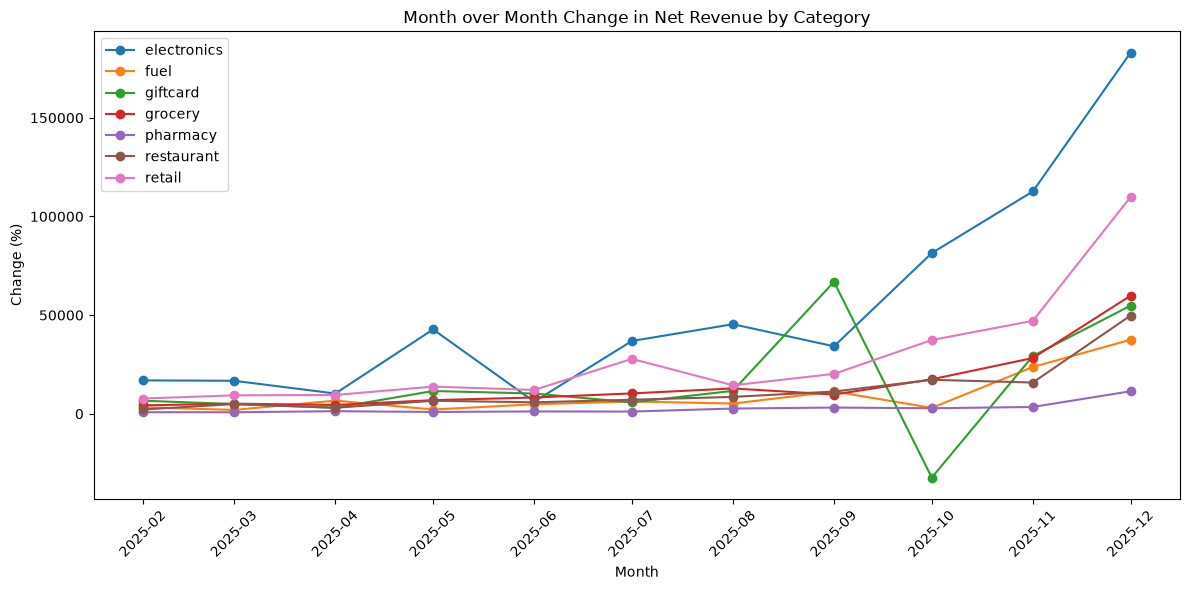

In [4]:
monthly_change_analysis = plot_metric("mom_change_eur", "Month over Month Change in Net Revenue by Category", "Change (%)")

In [5]:
def plot_activation_mom(db_path: str) -> pd.DataFrame:
    """
    Plot the month-over-month change in 30-day wallet activation rate
    by signup cohort.

    Parameters
    ----------
    db_path : str
        Path to the DuckDB database.

    Returns
    -------
    pandas.DataFrame
        Data used to generate the plot.
    """
    con = duckdb.connect(db_path)

    df = con.execute("""
        SELECT
            signup_month,
            mom_change
        FROM fct_wallet_activation
        ORDER BY signup_month
    """).df()

    con.close()

    df["signup_month"] = pd.to_datetime(df["signup_month"])

    plt.figure(figsize=(12, 6))
    plt.plot(
        df["signup_month"],
        df["mom_change"] * 100,
        marker="o"
    )

    plt.axhline(0, linestyle="--", linewidth=1, color="black")
    plt.xlabel("Signup Month")
    plt.ylabel("MoM Activation Rate Change (Percentage Points)")
    plt.title("Month-over-Month Change in 30-Day Wallet Activation Rate")
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df

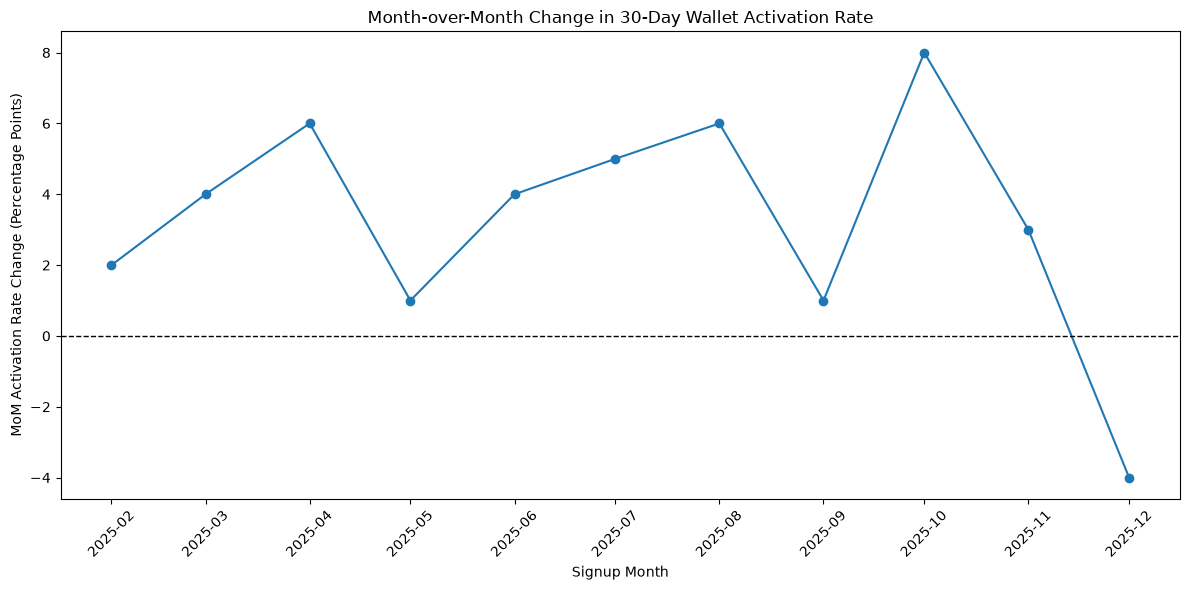

In [6]:
activation_rate_analysis = plot_activation_mom("../dev.duckdb")

In [7]:
def plot_wallet_status_rates(db_path: str) -> pd.DataFrame:
    """
    Plot wallet status rates by signup cohort and highlight cohorts
    that fall outside one standard deviation of the historical mean.

    Parameters
    ----------
    db_path : str
        Path to the DuckDB database.

    Returns
    -------
    pandas.DataFrame
        Data used to generate the plot.
    """
    con = duckdb.connect(db_path)

    df = con.execute("""
        select
            signup_month,
            active_rate,
            churned_rate,
            blocked_rate
        from fct_wallet_activation
        order BY signup_month
    """).df()

    con.close()

    df["signup_month"] = pd.to_datetime(df["signup_month"])

    # Calculate historical baselines
    active_mean = df["active_rate"].mean()
    active_sd = df["active_rate"].std()
    active_threshold = active_mean - active_sd

    churned_mean = df["churned_rate"].mean()
    churned_sd = df["churned_rate"].std()
    churned_threshold = churned_mean + churned_sd

    blocked_mean = df["blocked_rate"].mean()
    blocked_sd = df["blocked_rate"].std()
    blocked_threshold = blocked_mean + blocked_sd

    # Flag anomalous cohorts
    flagged_active = df[df["active_rate"] < active_threshold]
    flagged_churned = df[df["churned_rate"] > churned_threshold]
    flagged_blocked = df[df["blocked_rate"] > blocked_threshold]

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        df["signup_month"],
        df["active_rate"] * 100,
        marker="o",
        label="Active"
    )

    plt.plot(
        df["signup_month"],
        df["churned_rate"] * 100,
        marker="o",
        label="Churned"
    )

    plt.plot(
        df["signup_month"],
        df["blocked_rate"] * 100,
        marker="o",
        label="Blocked"
    )

    # Threshold lines
    plt.axhline(
        active_threshold * 100,
        linestyle="--",
        linewidth=1,
        label=f"Active -1 SD ({active_threshold:.1%})"
    )

    plt.axhline(
        churned_threshold * 100,
        linestyle="--",
        linewidth=1,
        label=f"Churned +1 SD ({churned_threshold:.1%})"
    )

    plt.axhline(
        blocked_threshold * 100,
        linestyle="--",
        linewidth=1,
        label=f"Blocked +1 SD ({blocked_threshold:.1%})"
    )

    # Highlight anomalous Active points
    plt.scatter(
        flagged_active["signup_month"],
        flagged_active["active_rate"] * 100,
        s=120,
        zorder=5
    )

    # Highlight anomalous Churned points
    plt.scatter(
        flagged_churned["signup_month"],
        flagged_churned["churned_rate"] * 100,
        s=120,
        zorder=5
    )

    # Highlight anomalous Blocked points
    plt.scatter(
        flagged_blocked["signup_month"],
        flagged_blocked["blocked_rate"] * 100,
        s=120,
        zorder=5
    )

    plt.xlabel("Signup Month")
    plt.ylabel("Rate (%)")
    plt.title("Wallet Status Risk Indicators by Signup Cohort")
    plt.legend()
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df

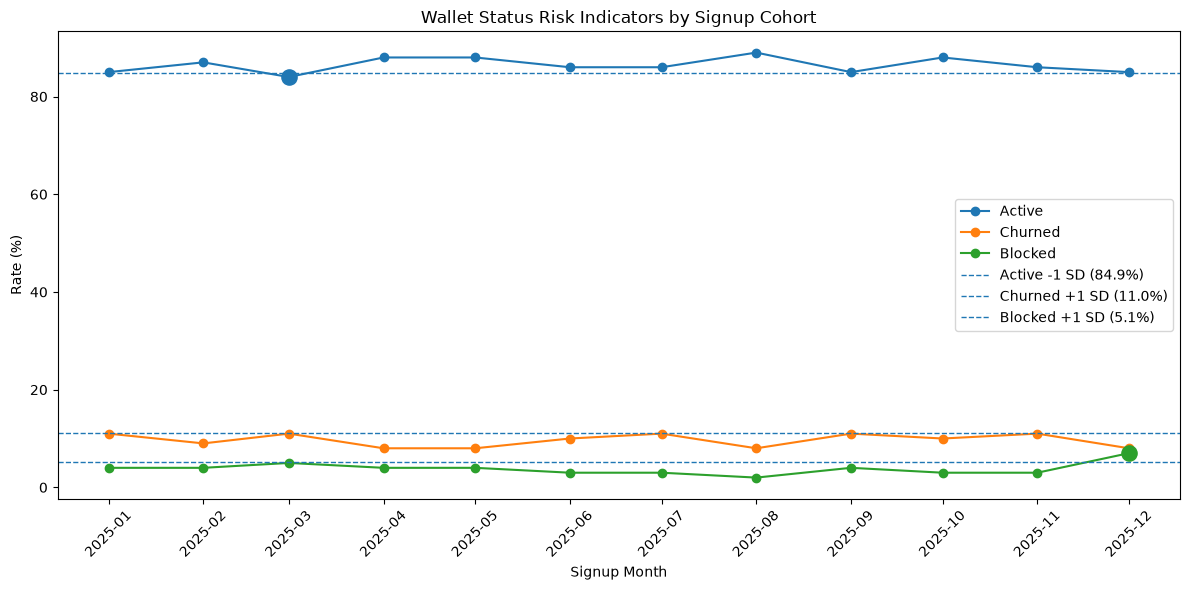

In [8]:
activity_analysis = plot_wallet_status_rates("../dev.duckdb")

In [12]:
def plot_giftcard_revenue_by_country(db_path="dev.duckdb"):
    """
    Plot monthly gift-card revenue by country group.

    Countries are grouped into:
    - Italy
    - Austria
    - Other

    Parameters
    ----------
    db_path : str
        Path to the DuckDB database.
    """

    # Connect to DuckDB
    con = duckdb.connect(db_path)

    # Load gift-card sales data
    giftcard_sales = con.sql("""
        SELECT
            month,
            country,
            authorized_eur
        FROM giftcard_sales
        ORDER BY month, country
    """).df()

    con.close()

    # Group countries into Italy, Austria, and Other
    giftcard_sales["country_group"] = giftcard_sales["country"].map(
        lambda x: x if x in ["IT", "AT"] else "Other"
    )

    # Aggregate revenue by month and country group
    plot_data = (
        giftcard_sales
        .groupby(["month", "country_group"], as_index=False)
        .agg(
            authorized_eur=("authorized_eur", "sum")
        )
    )

    months = ["2025-08", "2025-09", "2025-10"]
    country_order = ["IT", "AT", "Other"]

    plot_data["month"] = pd.Categorical(
        plot_data["month"],
        categories=months,
        ordered=True
    )

    plot_data["country_group"] = pd.Categorical(
        plot_data["country_group"],
        categories=country_order,
        ordered=True
    )

    plot_data = plot_data.sort_values(
        ["month", "country_group"]
    )

    # Create grouped bars
    x = np.arange(len(months))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    labels = {
        "IT": "Italy",
        "AT": "Austria",
        "Other": "Other"
    }

    for i, country in enumerate(country_order):
        data = (
            plot_data[plot_data["country_group"] == country]
            .set_index("month")
            .reindex(months)
        )

        ax.bar(
            x + (i - 1) * width,
            data["authorized_eur"],
            width,
            label=labels[country]
        )

    ax.set_title("Gift-Card Revenue by Country Group")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Revenue (€)")
    ax.set_xticks(x)
    ax.set_xticklabels(["Aug 2025", "Sep 2025", "Oct 2025"])
    ax.legend()

    plt.tight_layout()
    plt.show()

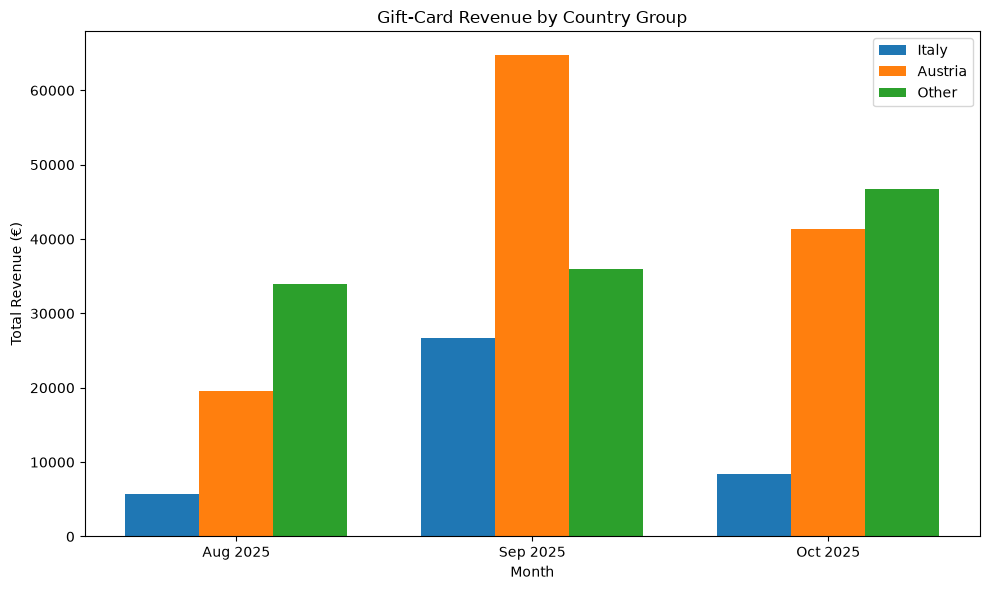

In [13]:
plot_giftcard_revenue_by_country("../dev.duckdb")